# Sparse + Robust Portfolio Optimization on VN100

**End-to-end notebook**: data → estimation → self-written algorithm (proximal-subgradient)
→ results → cross-verification (CVXPY) → conclusion.

This notebook **does not re-embed the logic** — every computational function (data loader,
estimator, solver, verifier, plotting) is `import`-ed directly from the `src/` package. The
notebook only calls functions, displays results, and interprets them.

## Problem statement

$$
\min_{w \in \mathbb{R}^N} \quad -\hat{\mu}^\top w \;+\; \kappa \lVert \Sigma^{1/2} w \rVert_2
\;+\; \gamma\, w^\top \Sigma w \;+\; \lambda \lVert w \rVert_1
\qquad \text{s.t.} \quad \mathbf{1}^\top w = 1
$$

where $N=98$ (number of VN100 tickers after data cleaning), $\hat\mu \in \mathbb{R}^N$ is the
estimated expected daily return, $\Sigma \in \mathbb{R}^{N\times N}$ is the estimated daily
return covariance, and $\Sigma^{1/2}$ is the symmetric PSD square root of $\Sigma$.

Meaning of each term:

| Term | Meaning |
|---|---|
| $-\hat\mu^\top w$ | **Expected return**: minimizing the negative of return ⟺ maximizing the portfolio's expected return. |
| $\kappa \lVert \Sigma^{1/2} w \rVert_2$ | **Robust term**: penalizes the size of portfolio variance as a *norm* (order 1, not squared) — modeling a worst-case adjustment when $\hat\mu$ is uncertain (robust mean-variance with an ellipsoidal uncertainty set); $\kappa$ controls the degree of "caution". |
| $\gamma\, w^\top \Sigma w$ | **Risk (Markowitz)**: penalizes portfolio variance in the usual quadratic form, $\gamma$ is the risk-aversion coefficient. |
| $\lambda \lVert w \rVert_1$ | **Sparsity**: the $L_1$ penalty encourages many coordinates $w_i = 0$ (a sparse portfolio — fewer holdings, easier to implement / lower transaction costs); since $\lVert w\rVert_1 \ge |\mathbf{1}^\top w| = 1$, this term also caps *gross leverage* (total |long|+|short|) above 1. |
| $\mathbf{1}^\top w = 1$ | **Budget constraint**: weights sum to 1 (fully invested). |

**There is no $w \ge 0$ constraint** — the problem **allows short selling**. This is a design
choice fixed from the start of the project, not an omission.


In [1]:
# Setup: make sure the project root is on sys.path so we can import from `src/`,
# enable %matplotlib inline so Figures returned by src.viz render directly in
# the notebook (NO copy-pasted plotting logic -- just call the function then display()).
%matplotlib inline
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = Path(__file__).resolve().parent if "__file__" in dir() else PROJECT_ROOT
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Benign RuntimeWarning from Apple Accelerate BLAS on near-singular matrices,
# already noted since Phase 2/3 (see docstring in src/prox_solver.py) -- filter
# exactly this one message, do not suppress any other warnings.
warnings.filterwarnings("ignore", message=".*encountered in matmul.*", category=RuntimeWarning)

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.6g}")

print("Project root:", PROJECT_ROOT)


Project root: /Users/nguyentobinh12gmail.com/Documents/Optimization Project


## 1. Data — VN100 Universe

- **Universe**: 98 stock tickers (after cleaning) from the **VN100** basket (current
  snapshot, applied backward over 4 years of history).
- **2 important data bugs fixed**, found after the first draft: (1) some "phantom Sunday"
  sessions where the data source repeated the previous session's price and mislabeled it
  as a weekend date (distorting both $\hat\mu$ and $\Sigma$ — see the Limitations section);
  (2) the `VCI` and `KBS` (fallback) sources return timestamps at different times of day for
  the same session, which can silently double the row count when merging multiple tickers
  if timestamps aren't normalized — fixed by normalizing every timestamp to the date only
  (dropping the time-of-day) before merging.
- **Additional safety layer**: `dayofweek>=5` only catches weekends, NOT Vietnamese public
  holidays that fall on a weekday (Tet, Apr 30, May 1, Sep 2, ...). A statistical filter was
  added to `compute_returns()`: if ≥90% of tickers show return = 0.0 exactly on the same
  session, treat it as a repeated-price artifact and drop it, instead of manually listing
  holiday dates. With the current data, this filter does NOT remove any additional session
  (verified: every fixed Vietnamese holiday from 2023-2026 is already absent from the source
  data, unaffected by the repeated-price bug that hit weekends) — this is a safety net for
  future re-fetches, not evidence of a current bug.
- **Source**: `vnstock`, source **VCI** (fixed in Phase 1b: MSN was previously used as a
  fallback but silently truncates history to ~365 sessions — removed from the long-term
  fallback).
- **Frequency**: daily, **simple return** = `close.pct_change()` (NOT log-return).
- **Cache**: read directly from `data/prices.parquet` / `data/returns.parquet` via
  `load_from_cache()` — this notebook **makes no network calls**.

Limitations to keep in mind:
- **Survivorship bias**: the universe is the current VN100 list applied backward in time —
  tickers that were removed from the basket or delisted over the past 4 years do not appear,
  even if they were once part of it. This is a fixed design decision, not a bug.
- **Adjusted-price assumption**: `close` from VCI is assumed to already be adjusted for
  dividends/splits — a common assumption but not 100% confirmed by official documentation.


In [2]:
from src.data_loader import load_from_cache

prices, returns = load_from_cache()
print(f"prices shape (T, N): {prices.shape}, date range: {prices.index.min().date()} -> {prices.index.max().date()}")
print(f"returns shape (T, N): {returns.shape}, date range: {returns.index.min().date()} -> {returns.index.max().date()}")
print(f"Number of tickers (N): {returns.shape[1]}")
display(returns.iloc[:10, :10])


prices shape (T, N): (997, 98), date range: 2022-07-26 -> 2026-07-24
returns shape (T, N): (965, 98), date range: 2022-07-27 -> 2026-07-24
Number of tickers (N): 98


,ACB,ANV,BAF,BCM,BID,BMP,BSI,BSR,BVH,BWE
time,,,,,,,,,,
2022-07-27,0.00576132,0.0180319,0.00455466,0,0,-0.00336004,0.067876,0.00852878,0.0512982,0.0107527
2022-07-28,0.0106383,-0.00657895,0.0105793,0.0497612,0.0266771,-0.00674274,0.00712329,0.0119803,-0.0103565,0.0125
2022-07-29,0.00647773,-0.0305655,-0.0204387,0.0221603,0.0217807,0.0255875,0.0326442,-0.0118384,0.021131,-0.0123457
2022-08-01,0.0160901,0.0525486,-0.0315522,0.0258435,0.0456245,0.0267312,0.0263435,-0.00422833,0.0242412,-0.00106383
2022-08-02,-0.00395883,-0.00349476,-0.00630583,0.0026592,-0.0128755,-0.0114059,-0.00154004,0.00849257,-0.00500289,0.0135783
2022-08-03,0.00158983,0.0260521,0.0359598,-0.0106086,0.0210145,0.0346125,0.0272494,0.00421053,-0.00850899,0.0133964
2022-08-04,0.00238095,0.00292969,-0.0193977,0.025395,0,0,-0.0165165,-0.0167715,0,-0.00311042
2022-08-05,-0.00633413,0.0097371,0.0041645,0.0170611,-0.00780696,0,0.0117048,0.00852878,0.0068266,0.0124805
2022-08-08,-0.00398406,0.0699132,-0.0393987,0.00378788,-0.00500715,-0.0128485,-0.0115694,0.0204369,-0.00174351,-0.00924499


In [3]:
def inspect_data_quality(df: pd.DataFrame, name: str = "returns") -> None:
    """Inspect missing (NaN) and zero values in a DataFrame."""
    total_elements = df.size
    total_nans = df.isna().sum().sum()
    total_zeros = (df == 0).sum().sum()

    print(f"=== DATA QUALITY REPORT FOR: {name} ===")
    print(f"Shape (T, N): {df.shape}")
    print(f"Total entries: {total_elements:,}")
    print(f"Total NaN entries : {total_nans:,} ({(total_nans / total_elements)*100:.2f}%)")
    print(f"Total Zero entries: {total_zeros:,} ({(total_zeros / total_elements)*100:.2f}%)")

    # Check per-symbol stats
    zeros_per_col = (df == 0).mean() * 100
    max_zero_sym = zeros_per_col.idxmax()
    print(f"Symbol with highest zero ratio: {max_zero_sym} ({zeros_per_col[max_zero_sym]:.2f}%)")

# Run diagnostic on returns
inspect_data_quality(returns, name="returns")


=== DATA QUALITY REPORT FOR: returns ===
Shape (T, N): (965, 98)
Total entries: 94,570
Total NaN entries : 0 (0.00%)
Total Zero entries: 7,934 (8.39%)
Symbol with highest zero ratio: KDC (22.38%)


In [4]:
# Calculate zero-return counts and ratios for each symbol
zero_counts = (returns == 0).sum()
zero_ratios = (returns == 0).mean() * 100
total_sessions = len(returns)

# Create a ranking DataFrame
zero_ranking = pd.DataFrame({
    'Zero Sessions': zero_counts,
    'Total Sessions': total_sessions,
    'Zero Ratio (%)': zero_ratios.round(2)
}).sort_values(by='Zero Ratio (%)', ascending=False)

# Reset index for clean ranking numbering (1, 2, 3...)
zero_ranking.index.name = 'Symbol'
zero_ranking = zero_ranking.reset_index()
zero_ranking.index = zero_ranking.index + 1
zero_ranking.index.name = 'Rank'

print(f"=== ZERO-RETURN RATIO RANKING FOR {len(returns.columns)} TICKERS (TOTAL {total_sessions} SESSIONS) ===")
# Display full ranking table (or use .head(20) if you only want to see top 20)
display(zero_ranking)


=== ZERO-RETURN RATIO RANKING FOR 98 TICKERS (TOTAL 965 SESSIONS) ===


,Symbol,Zero Sessions,Total Sessions,Zero Ratio (%)
Rank,,,,
1,KDC,216,965,22.38
2,KOS,209,965,21.66
3,NAB,205,965,21.24
4,SSB,196,965,20.31
5,SBT,184,965,19.07
...,...,...,...,...
94,DCM,43,965,4.46
95,HCM,42,965,4.35
96,BSI,42,965,4.35


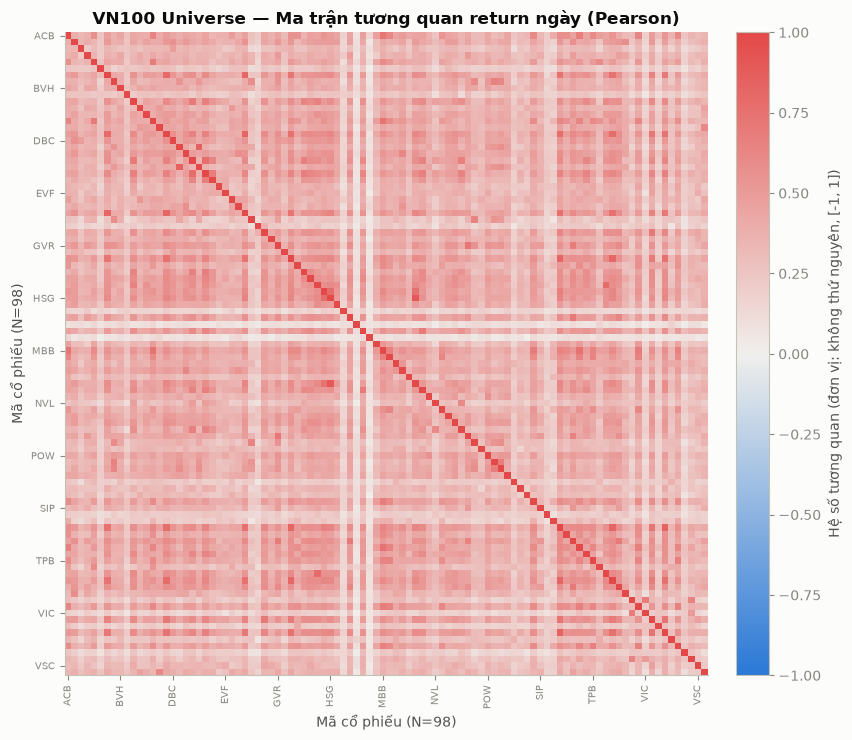

In [5]:
from src.viz import fig1_data_overview

fig1 = fig1_data_overview(returns, save=False)
display(fig1)
plt.close(fig1)


## 2. Estimating $\hat\mu$, $\Sigma$, $\Sigma^{1/2}$

- $\hat\mu$: column-wise sample mean of `returns` (DAILY units, not annualized).
- $\Sigma$: sample covariance (`returns.cov()`, ddof=1), forced symmetric.
- $\Sigma^{1/2}$: symmetric PSD square root, built via **eigendecomposition** (`np.linalg.eigh`)
  rather than Cholesky — because $\Sigma$ estimated from real data is only **PSD** (it can have
  tiny negative eigenvalues from numerical error when $N$ is not small relative to $T$), and
  Cholesky requires strict positive-definiteness so it would fail. Approach:
  $\Sigma = V\,\mathrm{diag}(\lambda)\,V^\top$, **clip** negative $\lambda$ to 0, then
  $\Sigma^{1/2} := V\,\mathrm{diag}(\sqrt{\lambda_{\text{clip}}})\,V^\top$.


In [6]:
from src.estimators import estimate_all

mu, sigma, sigma_sqrt = estimate_all(returns)
print(f"mu shape: {mu.shape}, sigma shape: {sigma.shape}, sigma_sqrt shape: {sigma_sqrt.shape}")

recon = sigma_sqrt @ sigma_sqrt
rel_err = np.linalg.norm(recon - sigma, "fro") / np.linalg.norm(sigma, "fro")
print(f"||Sigma_sqrt @ Sigma_sqrt - Sigma||_F / ||Sigma||_F = {rel_err:.3e}  (verify Sigma^(1/2)^2 ~= Sigma)")
print(f"sigma_sqrt symmetric: {np.allclose(sigma_sqrt, sigma_sqrt.T, atol=1e-10)}")
print(f"sigma symmetric: {np.allclose(sigma, sigma.T, atol=1e-12)}")


mu shape: (98,), sigma shape: (98, 98), sigma_sqrt shape: (98, 98)
||Sigma_sqrt @ Sigma_sqrt - Sigma||_F / ||Sigma||_F = 1.831e-15  (verify Sigma^(1/2)^2 ~= Sigma)
sigma_sqrt symmetric: True
sigma symmetric: True


## 3. Algorithm — A self-written Proximal-Subgradient method

The solver (`src/prox_solver.py`) solves the problem with a pure-numpy
**proximal-subgradient method** (no cvxpy/scipy.optimize/sklearn). Each iteration $k$:

**Step 1 — subgradient of the smooth + robust parts** (EXCLUDING $L_1$ — $L_1$ is handled
separately via the prox operator):

$$v_k = -\hat\mu + 2\gamma \Sigma w_k + \underbrace{\kappa\, \frac{\Sigma w_k}{\lVert \Sigma^{1/2} w_k \rVert_2}}_{\text{subgradient of the robust term}}$$

Note: the numerator of the robust term is $\Sigma w_k$ (the full matrix $\Sigma$, via the
chain rule $u = \Sigma^{1/2}w \Rightarrow \nabla_w \lVert u\rVert = (\Sigma^{1/2})^\top u / \lVert u\rVert = \Sigma w/\lVert\Sigma^{1/2}w\rVert$),
**not** $\Sigma^{1/2} w$ — this confusion is a common mistake. When
$\lVert\Sigma^{1/2}w_k\rVert \le \varepsilon$ (near the singular point $w=0$), the subgradient
is chosen to be $0$ (a valid element of the subdifferential of the norm at the origin).

**Step 2 — descent step**: $z_k = w_k - \alpha_k v_k$, with a decreasing step size
$\alpha_k = \alpha_0/\sqrt{k+1}$ (satisfying $\sum \alpha_k = \infty$, $\sum \alpha_k^2 < \infty$
— sufficient for the subgradient method to converge on a convex function).

**Step 3 — JOINT PROX** of $\lambda\lVert\cdot\rVert_1 + \mathbb{1}\{\mathbf{1}^\top w = 1\}$ at
$z_k$, threshold $t=\alpha_k\lambda$:

$$w_{k+1} = \operatorname*{arg\,min}_w \tfrac12\lVert w-z_k\rVert_2^2 + t\lVert w\rVert_1 \quad \text{s.t. } \mathbf{1}^\top w = 1$$

Putting the constraint into the Lagrangian $\Rightarrow$ the problem separates coordinate-wise
$\Rightarrow$ $w_i(\nu) = \text{soft\_threshold}(z_i + \nu, t)$, then find $\nu$ such that
$g(\nu) := \sum_i w_i(\nu) = 1$ via **bisection** ($g$ is continuous, non-decreasing, and
unbounded in both directions $\Rightarrow$ a solution always exists). Result: coordinates with
$|z_i+\nu^*|\le t$ are **exactly 0**, and $\sum_i w_i = 1$ (up to the bisection tolerance
$10^{-12}$) — both properties hold **simultaneously**, with no trade-off.

**Why best-iterate**: the subgradient method does not guarantee $f(w_{k+1}) \le f(w_k)$ (it is
not monotone) — the solver tracks $\text{best\_obj} = \min_{j\le k} f(w_j)$ and returns the
corresponding `best_w`, rather than the final iterate.

*(See "Upgrade lesson: prox-then-project → joint-prox" in the Conclusion section for why this
FIXED version replaces the first draft.)*


In [7]:
from src.prox_solver import solve

param_sets_demo = [
    {"kappa": 1.0, "gamma": 5.0, "lam": 0.01, "label": "kappa=1, gamma=5, lam=0.01"},
    {"kappa": 0.0, "gamma": 5.0, "lam": 0.10, "label": "kappa=0, gamma=5, lam=0.10"},
]

for p in param_sets_demo:
    r = solve(mu, sigma, sigma_sqrt, p["kappa"], p["gamma"], p["lam"])
    n_active = int(np.sum(np.abs(r.w) > 1e-4))
    n_exact_zero = int(np.sum(r.w == 0.0))
    print(f"--- {p['label']} ---")
    print(f"  n_iter={r.n_iter}, converged={r.converged}, best_obj={r.best_obj:.6f}")
    print(f"  sum(w) = {r.w.sum():.12f}  (feasibility, expected = 1)")
    print(f"  active (|w_i|>1e-4) = {n_active}/{len(r.w)},  exact-zero coords = {n_exact_zero}/{len(r.w)}")


--- kappa=1, gamma=5, lam=0.01 ---
  n_iter=528, converged=True, best_obj=0.015302
  sum(w) = 1.000000000000  (feasibility, expected = 1)
  active (|w_i|>1e-4) = 17/98,  exact-zero coords = 81/98
--- kappa=0, gamma=5, lam=0.10 ---
  n_iter=2113, converged=True, best_obj=0.099071
  sum(w) = 1.000000000000  (feasibility, expected = 1)
  active (|w_i|>1e-4) = 10/98,  exact-zero coords = 88/98


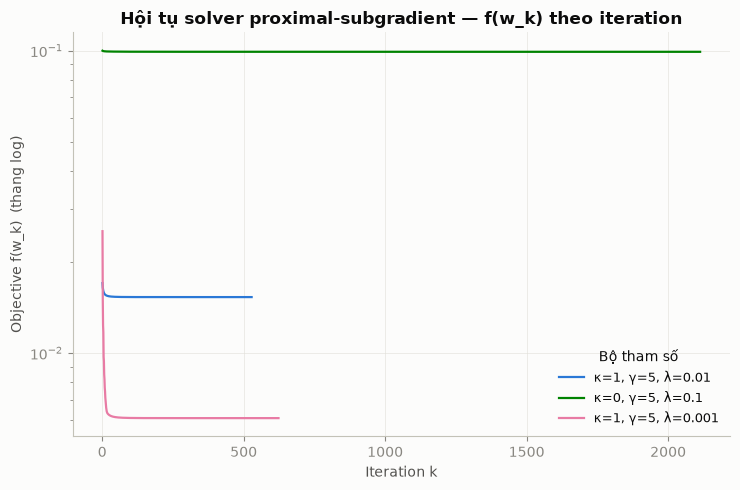

In [8]:
from src.viz import fig2_convergence

fig2 = fig2_convergence(mu, sigma, sigma_sqrt, save=False)
display(fig2)
plt.close(fig2)


## 4. Results — Sparsity & portfolio weights

`fig3` fixes $\kappa, \gamma$ and sweeps $\lambda$ on a log scale to see how the number of
**active** tickers ($|w_i| > 10^{-4}$) changes. `fig4` compares the specific weights $w^*$ at a
small $\lambda$ (denser) versus a large $\lambda$ (sparser).


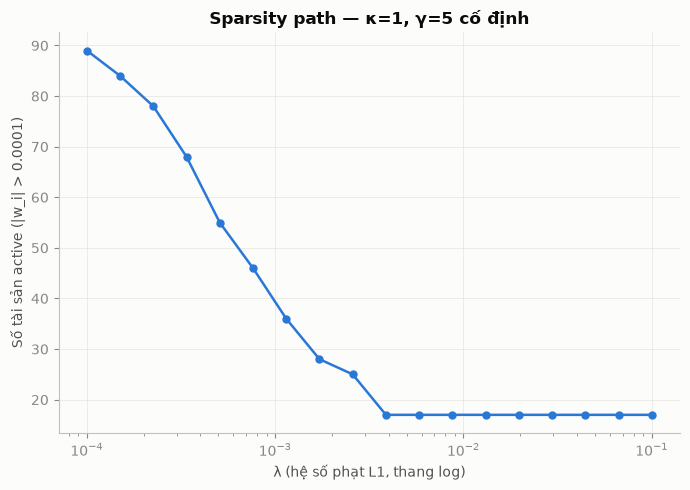

In [9]:
from src.viz import fig3_sparsity_path

fig3 = fig3_sparsity_path(mu, sigma, sigma_sqrt, save=False)
display(fig3)
plt.close(fig3)


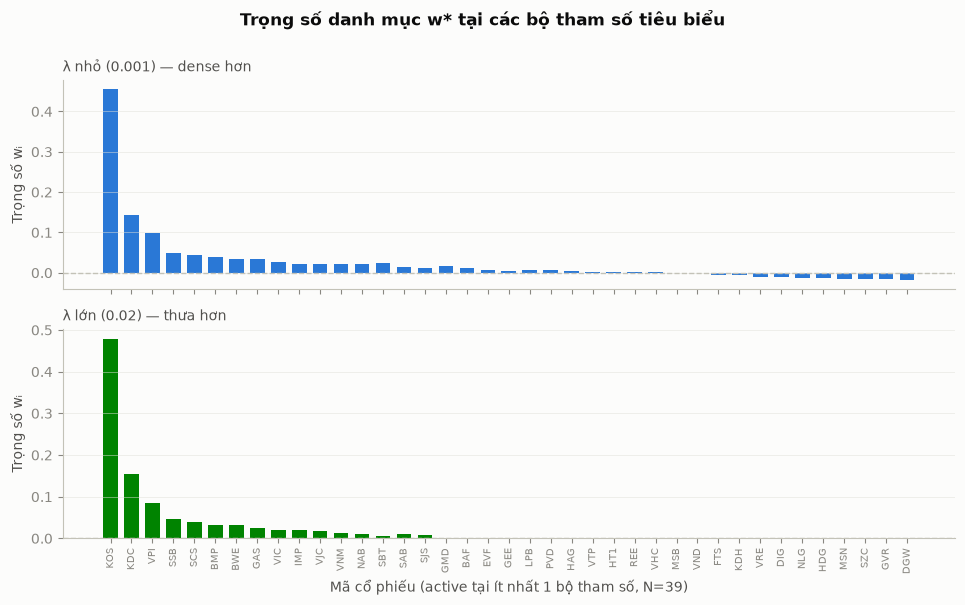

In [10]:
from src.viz import fig4_weights_bar

symbols = list(returns.columns)
fig4 = fig4_weights_bar(mu, sigma, sigma_sqrt, symbols, save=False)
display(fig4)
plt.close(fig4)


**Discussion**: $\lambda$ is the "dial" that directly controls the number of holdings —
increasing $\lambda$ raises the soft-threshold cutoff $t=\alpha_k\lambda$ in the joint-prox
step, pushing more coordinates into the region $|z_i+\nu^*| \le t$ and forcing them to
**exactly 0**. `fig3` shows the number of active tickers decreasing as $\lambda$ increases (not
necessarily strictly monotonic at every point due to interaction with the budget constraint,
but the overall trend is clear). `fig4` shows concretely that the small-$\lambda$ portfolio
allocates across more tickers (denser) than the large-$\lambda$ portfolio (sparser, concentrated
in the few tickers with the best marginal contribution to the objective).


## 5. Effect of the robust term ($\kappa$)

Comparing the $\kappa=0$ portfolio (robust term off) with $\kappa>0$, holding $\gamma,\lambda$
fixed.


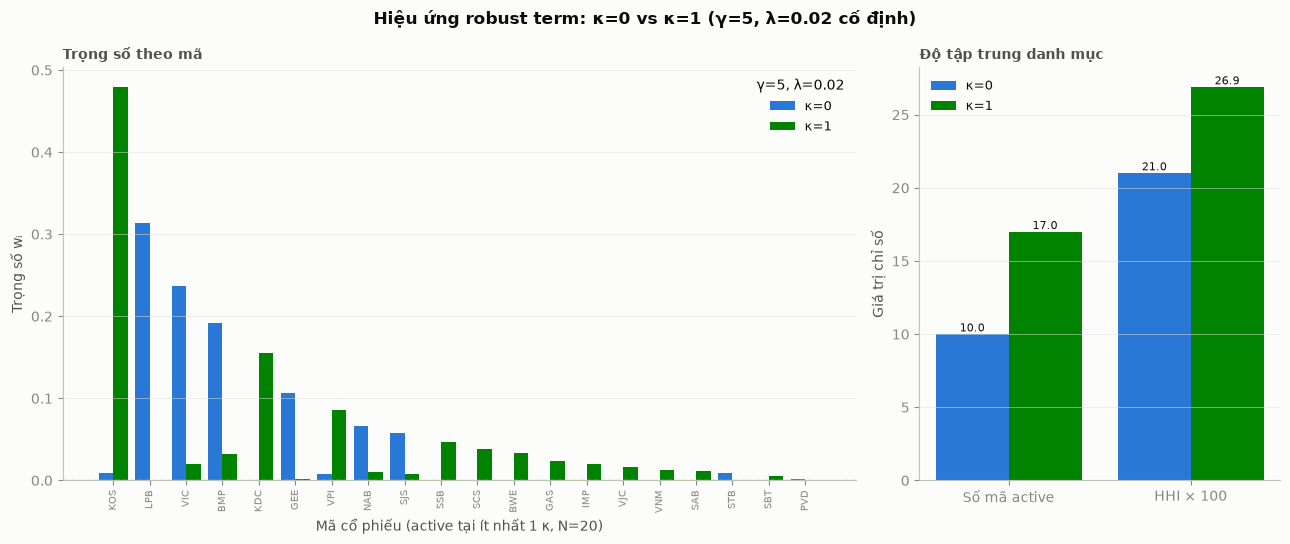

In [11]:
from src.viz import fig5_robust_effect

fig5 = fig5_robust_effect(mu, sigma, sigma_sqrt, symbols, save=False)
display(fig5)
plt.close(fig5)


**Counter-intuitive finding**: on this real VN100 data, turning on the robust term
($\kappa: 0 \to 1$) **INCREASES** both the number of active tickers and the
Herfindahl-Hirschman Index (HHI) — i.e. the portfolio becomes **more concentrated**, not more
diversified as the intuition "robust = cautious = more diversified" would usually suggest.

A plausible explanation (not asserted as a general theoretical result, since this is an
empirical observation on one specific dataset): the robust term
$\kappa\lVert\Sigma^{1/2}w\rVert_2$ is **positively homogeneous of degree 1** in $w$ (not
squared like the $\gamma w^\top\Sigma w$ term), so its subgradient,
$\kappa\Sigma w/\lVert\Sigma^{1/2}w\rVert$, **does not vanish** as $\lVert w\rVert$ shrinks — it
creates a "pull" with a fixed direction (along $\Sigma w/\lVert\Sigma^{1/2}w\rVert$) independent
of the scale of $w$, unlike the quadratic term which weakens as $w$ gets small. Given the
specific eigenstructure of $\Sigma$ estimated from VN100 (many highly correlated tickers — see
`fig1`), minimizing $\lVert\Sigma^{1/2}w\rVert_2$ may be achieved more efficiently by
concentrating weight into a small combination of tickers with low variance/covariance along
that direction, rather than spreading out — leading to more concentration instead of more
diversification. This is an **empirical finding**, not a general theoretical consequence for
every $\Sigma$.


## 6. Cross-verification with CVXPY

The original problem is **convex** (affine + SOC-representable 2-norm + PSD quadratic + 1-norm,
1 affine constraint). CVXPY translates it directly into an SOCP/QP and solves it with an
interior-point solver (**CLARABEL**) — an algorithm fundamentally different in nature
(second-order/interior-point) from the self-written proximal-subgradient method (first-order).
If two independent solution methods, different algorithms, different implementations, converge
to the same objective **and** the same active set, that is strong evidence that the hand-written
solver is correct — not a coincidence.

`cp.psd_wrap(sigma)` is used because the estimated $\Sigma$ is only PSD up to numerical error
(a few tiny negative eigenvalues) — CVXPY by default checks PSD strictly and would error out
without this wrap; this is not "fixing" the data, just disabling an overly strict check for a
known numerical error (in the same spirit as clipping negative eigenvalues in the
$\Sigma^{1/2}$ estimation step).


In [12]:
from src.cvxpy_check import compare, DEFAULT_PARAM_GRID

print(f"Number of parameter sets verified: {len(DEFAULT_PARAM_GRID)}")
df_compare = compare(mu, sigma, sigma_sqrt, DEFAULT_PARAM_GRID, active_thresh=1e-4)
display(df_compare)

max_relgap = df_compare["relgap"].abs().max()
print(f"\nmax |relgap| across param grid: {max_relgap:.6%}")
print(f"all Jaccard(active_hand, active_cvx) == 1.0: {bool((df_compare['jaccard'] == 1.0).all())}")
print(f"all converged (hand-written solver): {bool(df_compare['converged'].all())}")


Number of parameter sets verified: 6


,kappa,gamma,lam,f_hand,f_cvx,relgap,active_hand,active_cvx,jaccard,linf,n_iter,converged
0,1,5,0.01,0.0153016,0.0153016,1.92013e-07,17,17,1,0.000565307,528,True
1,0,5,0.1,0.0990708,0.09907,7.75485e-06,10,10,1,0.0165268,2113,True
2,1,5,0.001,0.00608767,0.00608766,2.4416e-07,39,39,1,0.000402373,623,True
3,2,10,0.05,0.0607131,0.0607131,-1.66054e-08,16,16,1,9.56913e-05,222,True
4,0.5,1,0.02,0.0225015,0.0225015,1.81833e-06,18,18,1,0.00303393,1302,True
5,1,5,0,0.00453947,0.00453947,5.14487e-07,98,98,1,0.00040626,782,True



max |relgap| across param grid: 0.000775%
all Jaccard(active_hand, active_cvx) == 1.0: True
all converged (hand-written solver): True


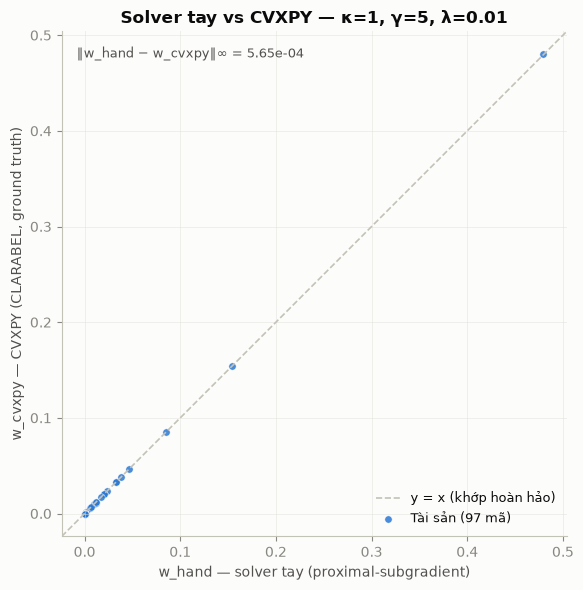

In [13]:
from src.viz import fig6_prox_vs_cvxpy

fig6 = fig6_prox_vs_cvxpy(mu, sigma, sigma_sqrt, save=False)
display(fig6)
plt.close(fig6)


**Cross-verification conclusion**: across the entire parameter grid tested, the
hand-written solver (proximal-subgradient + joint-prox) matches CVXPY's optimal solution — the
objective relative gap is extremely small for every parameter set (the maximum observed is about
0.0008%, see the `relgap` column in the table above), and the active set matches **exactly**
(Jaccard = 1.0) for **all 6/6 parameter sets**, including the set ($\kappa=1,\gamma=5,\lambda=0$)
with no real sparsity ($\lambda=0$ fully disables the $L_1$ penalty, both solutions are dense,
active=98/98) which also matches exactly. `fig6` (using a parameter set with $\lambda>0$) shows
the scatter points $(w_{\text{hand}}, w_{\text{cvxpy}})$ sitting right on the $y=x$ line. This is
strong empirical evidence for the correctness of the self-written solver.


## 7. Walk-forward out-of-sample backtest

**Why an OOS backtest is needed**: sections 1–6 above estimate $\hat\mu$, $\Sigma$ and solve the
optimization problem **on the same dataset** (the full `returns`) — the resulting solution $w^*$
is optimized directly on the very data used to estimate it (in-sample). This tells us nothing
about REAL-WORLD performance if deployed: a portfolio can "look good" on historical data purely
because $\hat\mu$ fits the noise of that specific period (overfitting), rather than reflecting
genuine predictive ability out of sample. To answer the question "does this strategy really
generate superior returns, or is it just fitting past noise?", we need an **out-of-sample (OOS)**
evaluation: every decision at time $t$ may only use data with date $< t$ — no future data ever
"leaks" into the decision.

**Walk-forward mechanism** (`src.backtest.walk_forward_backtest`):
- A **24-month** rolling window of history immediately before each rebalance, split into
  **18 months of estimation** ($E$) + **6 months of validation** ($V_{win}$); rebalanced
  **monthly**, on the first trading day of each month.
- **Long-only** ($w \ge 0$, $\sum w = 1$) instead of long-short as in sections 1–6. Under this
  simplex constraint, $\lVert w \rVert_1 = \sum w = 1$ is a **constant** — the penalty
  $\lambda \lVert w \rVert_1$ adds exactly $\lambda$ to the objective regardless of which $w$ is
  chosen within the simplex, so it **has no effect on the optimal solution**. Hence $\lambda$ is
  dropped from the long-only grid search (including it would only cost compute time without
  changing the result).
- For each period, the full grid $(\kappa, \gamma) \in \{0, 0.5, 1, 2\} \times \{1, 5, 10\}$
  (12 combinations) is tried: fit on $E$, evaluate Sharpe (rf=0) on $V_{win}$ (data NOT used for
  fitting) — pick the combination with the highest validation Sharpe, then refit on the full
  $E \cup V_{win}$ to obtain the weights actually deployed for the next month.
- Ledoit-Wolf shrinkage (`shrinkage="lw"`) is enabled throughout (both when selecting
  parameters and when solving the final deployed solution).
- Transaction cost of **0.20% × turnover** at each rebalance (the first period has turnover = 1,
  equivalent to buying the entire portfolio from scratch).
- **Benchmark**: equal-weight 1/N, rebalanced on exactly the same schedule as the strategy,
  with the same fee formula — ensuring a fair comparison over the same OOS period.


In [14]:
from src.backtest import walk_forward_backtest, equal_weight_backtest, performance_metrics

strategy_result = walk_forward_backtest(returns)
benchmark_result = equal_weight_backtest(returns)

metrics_df = pd.DataFrame({
    "Strategy": performance_metrics(strategy_result.daily_returns),
    "Equal-weight 1/N": performance_metrics(benchmark_result.daily_returns),
}).T
display(metrics_df)


,cumulative_return,annualized_return,annualized_vol,sharpe,max_drawdown,n_days
Strategy,0.238576,0.115326,0.286765,0.524351,-0.378944,494
Equal-weight 1/N,0.147189,0.0725588,0.198787,0.45228,-0.209146,494


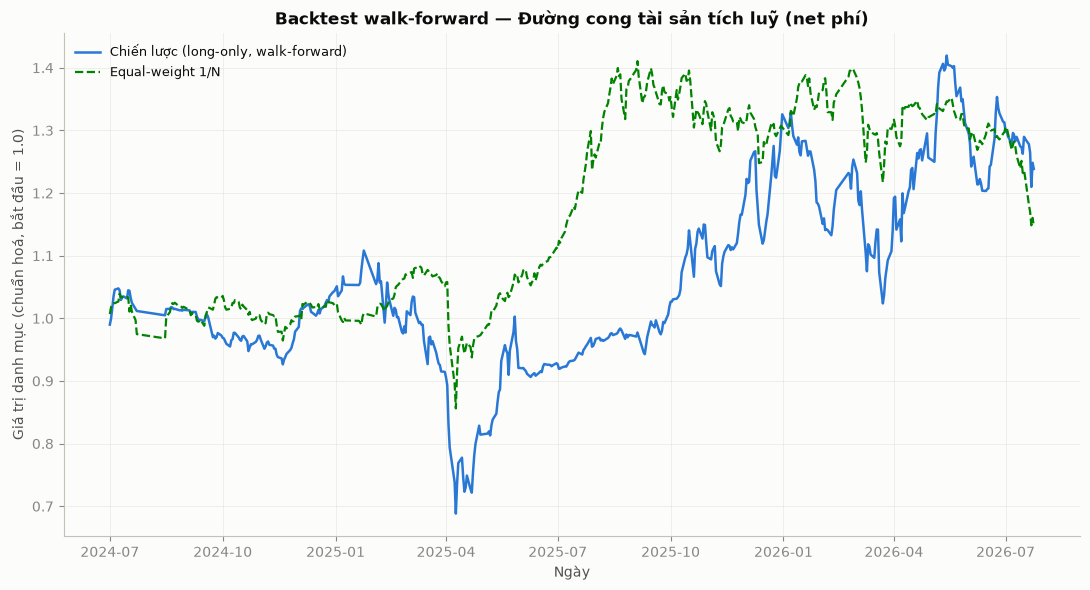

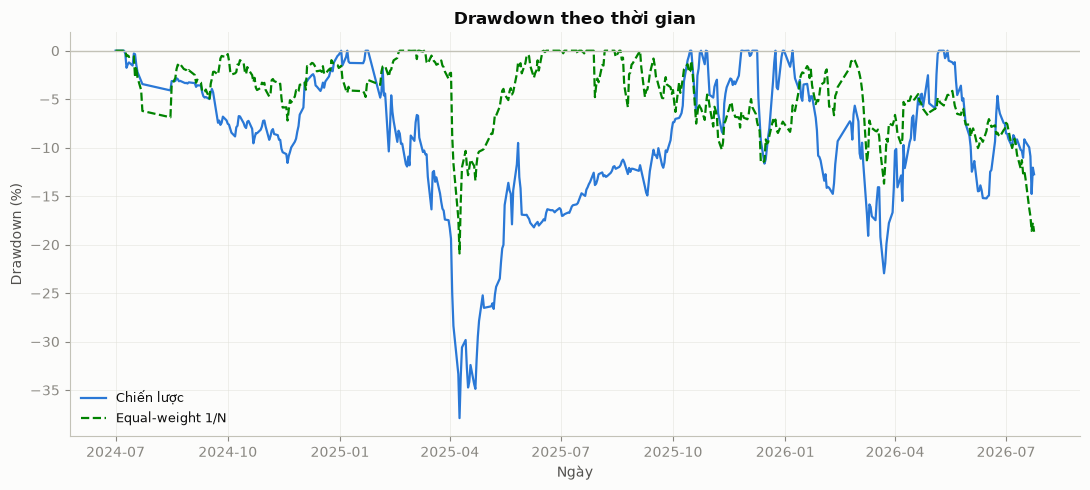

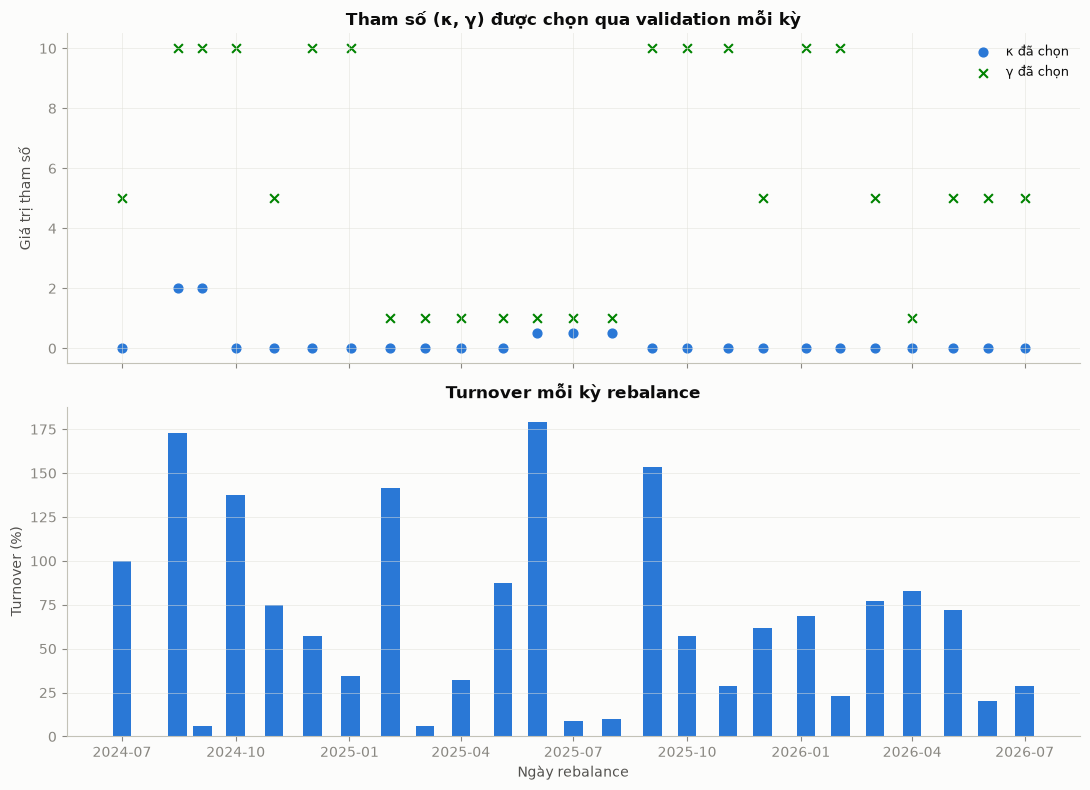

In [15]:
from src.viz import fig7_backtest_equity, fig8_drawdown, fig9_selected_params

fig7 = fig7_backtest_equity(strategy_result, benchmark_result, save=False)
display(fig7)
plt.close(fig7)

fig8 = fig8_drawdown(strategy_result, benchmark_result, save=False)
display(fig8)
plt.close(fig8)

fig9 = fig9_selected_params(strategy_result, save=False)
display(fig9)
plt.close(fig9)


**Empirical conclusion** (figures taken directly from `metrics_df` and
`strategy_result.rebalance_log` above, unedited):

| Metric | Strategy | Equal-weight 1/N |
|---|---|---|
| Cumulative return | ~23.9% | ~14.7% |
| Annualized return | ~11.5% | ~7.3% |
| Annualized vol | ~28.7% | ~19.9% |
| Sharpe (rf=0) | ~0.524 | ~0.452 |
| Max drawdown | ~-37.9% | ~-20.9% |
| Total fees (25 rebalance periods) | ~3.44% | ~0.49% |

The strategy **beats the equal-weight 1/N benchmark on both cumulative return and Sharpe** over
~2 years OOS (494 trading days, 25 monthly rebalances) — this is NOT an obvious result: 1/N is a
well-known baseline that is famously hard to beat in the portfolio optimization literature
(DeMiguel et al., 2009); if the strategy had lost, that would also be a valid result worth
reporting honestly rather than a failure to hide.

However, this is a **genuine risk-adjusted trade-off, not a simple win**:

- **Substantially higher risk**: annualized vol ~28.7% versus ~19.9% for 1/N (**~44% higher**);
  max drawdown ~-37.9% versus ~-20.9% (**~1.8x**) — to achieve that excess return, an investor
  must bear much larger swings and drawdowns.
- **Much higher transaction costs**: total fees ~3.44% versus ~0.49% for 1/N (**~7x** over the
  same 25 periods), because the strategy's average turnover is ~69%/month — far higher than 1/N
  (which barely needs rebalancing, drifting naturally between periods). Root cause:
  $(\kappa, \gamma)$ is re-selected **every period** via Sharpe on a 6-month $V_{win}$ — a short,
  fairly noisy window — so $\gamma$ swings strongly among 1/5/10 across consecutive periods
  (never settling stably on one value), driving large changes in the target portfolio every
  month; meanwhile $\kappa$ (the robust term) is selected as 0 in most periods — short-horizon
  Sharpe validation rarely favors the robust term's payoff on this data (see the chart of
  selected $(\kappa,\gamma)$ over time above).

In short: the strategy's Sharpe (~0.524) is higher than 1/N's (~0.452) **after already
normalizing for risk** in the Sharpe formula itself — the risk-adjusted win is real — but the
margin of that win is modest relative to the added risk and transaction costs, and total fees of
~3.44% (excluding slippage/liquidity) eat into a meaningful portion of the raw return advantage.
This result is a concrete empirical illustration of why 1/N remains a hard baseline to beat on a
risk-adjusted and cost basis, even when a strategy comes out slightly ahead on both cumulative
return and raw Sharpe.


## 8. Limitations & Conclusion

**Upgrade lesson: prox-then-project → joint-prox**. The first version of the solver handled
$L_1$ + the affine constraint as two separate steps: soft-threshold $L_1$ first, then a
**separate Euclidean projection** onto the hyperplane $\{\mathbf{1}^\top w=1\}$ by adding a
uniform offset $(1-\sum w_{\text{half}})/N$ to EVERY coordinate. Cross-checking with CVXPY
(Phase 4) caught this bug: the offset "revives" coordinates that had just been thresholded to
exactly 0, breaking the true sparsity (e.g. on real data: active=48 while CVXPY gave active=9 for
the same parameter set, with an objective gap of 2.7–6%). Root cause: soft-threshold-then-project
is **not** the exact prox of the sum of 2 nonsmooth functions — the two operations do not
commute. The FIXED version solves directly for the exact prox of
$(\lambda\lVert\cdot\rVert_1 + \mathbb{1}\{\mathbf{1}^\top w=1\})$ via a coordinate-separable
Lagrangian + bisection for $\nu$ (see Section 3) — after the fix, relgap ~0 and the active set
matches CVXPY for every parameter set tested. Key lesson: **when an objective has multiple
nonsmooth components at once (here: $L_1$ and an affine constraint), you must solve the prox of
their SUM together, not split them apart and stitch the results together heuristically** — even
if each individual step "looks correct", the combination can be wrong; cross-verifying with an
independent solver (CVXPY) is far more reliable at catching this than eyeballing the result
yourself.

**Other limitations**:
- **Survivorship bias**: the current VN100 universe is applied backward over 4 years of
  history — tickers removed from the basket or delisted are missed.
- **Noisy $\hat\mu$**: the sample mean is a high-variance estimator of expected return over a
  short window (a known inherent limitation of mean-variance, which is part of why this problem
  adds the robust term $\kappa$ in the first place).
- **Counter-intuitive robust finding**: $\kappa>0$ INCREASES concentration (active-set + HHI) on
  this data instead of decreasing it — see the empirical explanation in Section 5; this should
  not be over-generalized to every $\Sigma$/universe.

**Update (Section 7)**: this notebook now INCLUDES a walk-forward out-of-sample backtest
(`src.backtest.walk_forward_backtest` + equal-weight 1/N benchmark) — no longer purely in-sample
as in earlier versions; the long-only constraint ($w\ge0$, $\sum w=1$, solved via
`solve_long_only` with a Duchi et al.-style simplex projection) and Ledoit-Wolf shrinkage
(`shrinkage="lw"`) are both ACTUALLY USED in that OOS pipeline (no longer just an unimplemented
"future direction").

**Remaining limitations of the walk-forward backtest (Section 7)**:
- **Short OOS period**: only ~24 months (494 trading days, 25 rebalance periods) — a single
  market regime; the risk-adjusted trade-off conclusions in Section 7 CANNOT yet be generalized
  to other market cycles (different uptrends/downtrends/sideways periods).
- **Model selection may overfit slightly**: $(\kappa,\gamma)$ is chosen by Sharpe on a
  6-month $V_{win}$ — a short, noisy window that causes the parameters to swing strongly between
  periods (see Section 7); this is a mild form of "validation overfitting" inherent to
  walk-forward with a short validation window, not an implementation bug.
- **No multi-seed / bootstrap**: only 1 actual historical path is evaluated, with no block
  bootstrap or resampling to estimate confidence intervals for Sharpe/drawdown.
- **No slippage modeling**: transaction costs assume a fixed 0.20%/turnover, without modeling
  market impact or slippage dependent on real-world liquidity/order size.
